In [1]:
## Packages
# Importing Common Packages
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

# For time and memory logging
import time, os
import tracemalloc

# Importing LSTM Packages
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, BatchNormalization, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

# Importing Random Forest Packages
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Importing SVR Packages
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR

# Importing SARIMAX Package
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

# Importing XGBoost Regressor Package
import xgboost as xgb


In [2]:

## Dataset
### Importing Data
df = pd.read_csv('data/Turbine_Data.csv', parse_dates=['Unnamed: 0'], index_col=['Unnamed: 0'])
df.index = pd.to_datetime(df.index)

### Dataframe
df
df.info()
df.describe()
### Cleaning and Preprocessing Dataset
df.drop_duplicates(inplace=True)
df.drop(columns=['WTG', 'ControlBoxTemperature'], inplace=True)
df.isna().sum()
df = df[df['ActivePower'] >= 0]
df.dropna(subset=['ActivePower'], inplace=True)

### Checking Percentage of Missing Values
missing_percentage = df['ActivePower'].isna().sum() / len(df['ActivePower']) * 100
print(f'Percentage of missing values: {missing_percentage:.2f}%')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118224 entries, 2017-12-31 00:00:00+00:00 to 2020-03-30 23:50:00+00:00
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ActivePower                   94750 non-null   float64
 1   AmbientTemperatue             93817 non-null   float64
 2   BearingShaftTemperature       62518 non-null   float64
 3   Blade1PitchAngle              41996 non-null   float64
 4   Blade2PitchAngle              41891 non-null   float64
 5   Blade3PitchAngle              41891 non-null   float64
 6   ControlBoxTemperature         62160 non-null   float64
 7   GearboxBearingTemperature     62540 non-null   float64
 8   GearboxOilTemperature         62438 non-null   float64
 9   GeneratorRPM                  62295 non-null   float64
 10  GeneratorWinding1Temperature  62427 non-null   float64
 11  GeneratorWinding2Temperature  62449 non-null   float64
 12

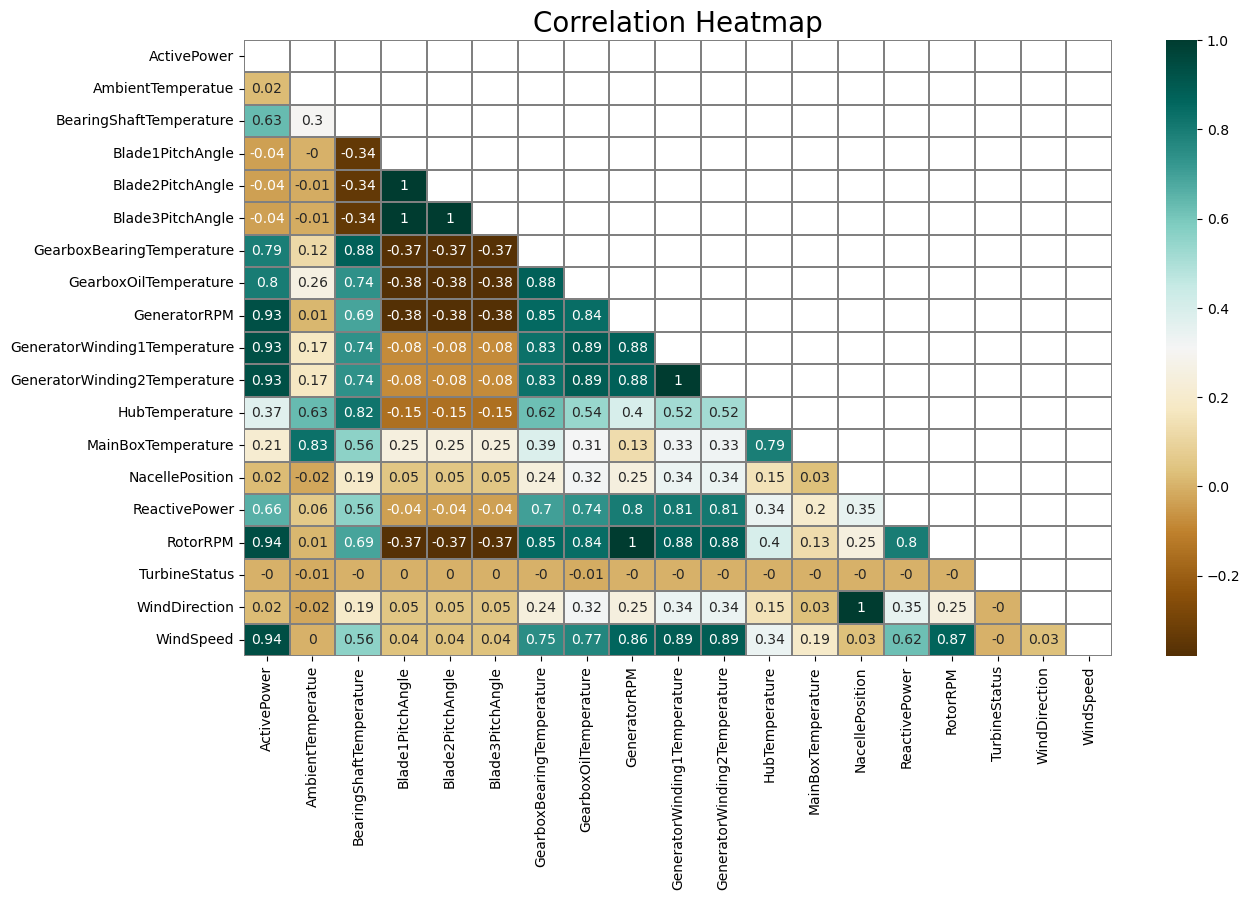

In [3]:
### Correlation Heatmap
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.subplots(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap="BrBG", linewidths=0.1, linecolor='gray')
plt.title('Correlation Heatmap', fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()



In [4]:
df = df[['ActivePower', 'WindSpeed']].dropna()

In [5]:
df_daily = df.resample('D').mean().dropna()

In [6]:
len(df_daily)

748

LSTM

Split Data into Train and Test sets


In [7]:
train_data, test_data = df_daily['ActivePower'][:698], df_daily['ActivePower'][698:748]

train_data.shape, test_data.shape

((698,), (50,))

In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
test_scaled = scaler.transform(test_data.values.reshape(-1, 1))

In [9]:
def split_sequences(data, n_steps_in, n_steps_out):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(data):
            break
        seq_x, seq_y = data[i:end_ix], data[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [10]:
n_steps_in, n_steps_out = 35, 15

X_train, y_train = split_sequences(train_scaled, n_steps_in, n_steps_out)
X_test, y_test = split_sequences(test_scaled, n_steps_in, n_steps_out)

In [11]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
y_test = y_test.reshape((y_test.shape[0], y_test.shape[1], 1))

In [12]:
tracemalloc.start()
start_time = time.time()

lstm_model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(n_steps_in, 1)),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    Dense(n_steps_out)
])
lstm_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=20, verbose=1)
history = lstm_model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_test, y_test), shuffle=False, callbacks=[early_stopping], verbose=0)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

lstm_time = end_time - start_time
lstm_mem = peak / (1024 ** 2)  # Convert bytes to MB

print(f"Training Time: {lstm_time:.2f} seconds")
print(f"Peak Memory Usage: {lstm_mem:.2f} MB")

/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 166: early stopping
Training Time: 57.95 seconds
Peak Memory Usage: 9.49 MB


In [13]:
predictions = lstm_model.predict(X_test, verbose=0)

predictions = scaler.inverse_transform(predictions)

In [14]:
predictions[0][0:15]

array([620.4839 , 635.3062 , 637.54785, 646.23267, 626.99493, 650.9149 ,
       632.50397, 664.86163, 678.68475, 625.0724 , 669.7786 , 675.2652 ,
       665.8405 , 705.13214, 691.9731 ], dtype=float32)

In [15]:
df_lstm = pd.DataFrame({'ActualPower': df_daily['ActivePower'][733:748], 'PredictedPower': predictions[0][0:15]}, index=df_daily[733:748].index)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Calculate metrics
r2_lstm = r2_score(df_lstm["ActualPower"], df_lstm["PredictedPower"])
mae_lstm = mean_absolute_error(df_lstm["ActualPower"], df_lstm["PredictedPower"])

# Manually calculate RMSE
mse = mean_squared_error(df_lstm["ActualPower"], df_lstm["PredictedPower"])
rmse_lstm = np.sqrt(mse)

# MAPE
mape_lstm = mean_absolute_percentage_error(df_lstm["ActualPower"], df_lstm["PredictedPower"])

# Print results
print(f"R² Score: {r2_lstm:.4f}")
print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAPE: {mape_lstm:.4f}")


R² Score: 0.0840
MAE: 145.3532
RMSE: 165.0272
MAPE: 0.2603


In [17]:
print('LSTM Model Evaluation:')
print(f'R-squared: {r2_lstm:.2f}')
print(f'MAE: {mae_lstm:.2f}')
print(f'RMSE: {rmse_lstm:.2f}')
print(f'MAPE: {mape_lstm:.2f}')

LSTM Model Evaluation:
R-squared: 0.08
MAE: 145.35
RMSE: 165.03
MAPE: 0.26


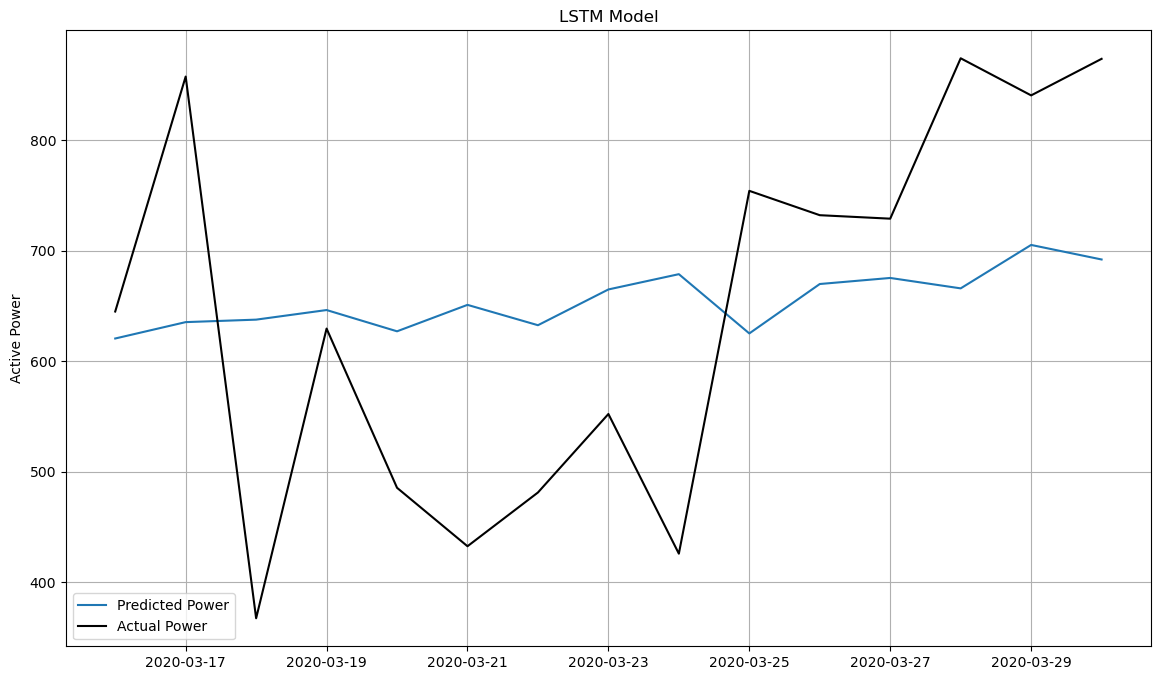

In [18]:
plt.figure(figsize=(14, 8))
plt.plot(df_lstm['PredictedPower'], label='Predicted Power')
plt.plot(df_lstm['ActualPower'], color='black', label='Actual Power')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.title("LSTM Model")
plt.show()

In [19]:
X_train_rf, X_test_rf = df_daily[['WindSpeed']][:733], df_daily[['WindSpeed']][733:748]
y_train_rf, y_test_rf = df_daily['ActivePower'][:733], df_daily['ActivePower'][733:748]

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((649, 35, 1), (1, 35, 1), (649, 15, 1), (1, 15, 1))

In [20]:
tracemalloc.start()
start_time = time.time()

rf_model = RandomForestRegressor(n_estimators=1000)
rf_model.fit(X_train_rf, y_train_rf)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

rf_time = end_time - start_time
rf_mem = peak / (1024 ** 2)

print(f"Training Time: {rf_time:.2f} seconds")
print(f"Peak Memory Usage: {rf_mem:.2f} MB")

Training Time: 4.53 seconds
Peak Memory Usage: 1.09 MB


In [21]:
rf_predictions = rf_model.predict(X_test_rf)

In [22]:
df_rf = pd.DataFrame({'ActualPower': y_test_rf, 'PredictedPower': rf_predictions}, index=y_test_rf.index)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Calculate metrics
r2_rf = r2_score(df_rf["ActualPower"], df_rf["PredictedPower"])
mae_rf = mean_absolute_error(df_rf["ActualPower"], df_rf["PredictedPower"])

# Manual RMSE calculation (avoid 'squared=False')
mse_rf = mean_squared_error(df_rf["ActualPower"], df_rf["PredictedPower"])
rmse_rf = np.sqrt(mse_rf)

# MAPE
mape_rf = mean_absolute_percentage_error(df_rf["ActualPower"], df_rf["PredictedPower"])

# Print results
print(f"R² Score (RF): {r2_rf:.4f}")
print(f"MAE (RF): {mae_rf:.4f}")
print(f"RMSE (RF): {rmse_rf:.4f}")
print(f"MAPE (RF): {mape_rf:.4f}")


R² Score (RF): 0.9138
MAE (RF): 40.3953
RMSE (RF): 50.6118
MAPE (RF): 0.0637


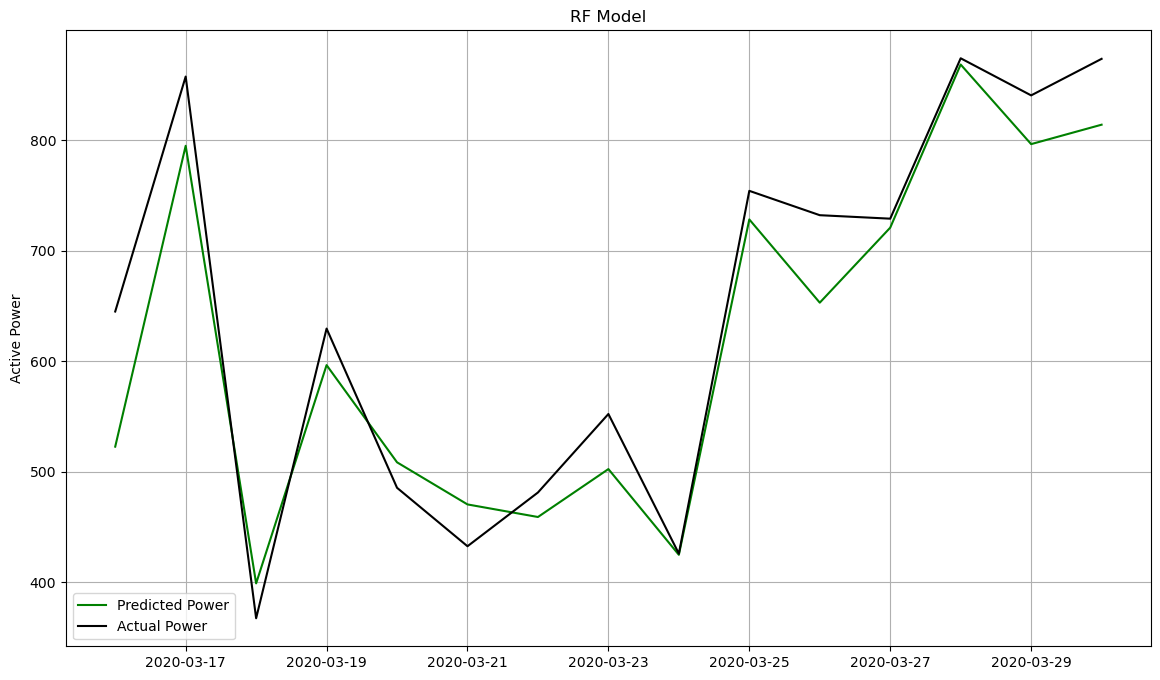

In [24]:
plt.figure(figsize=(14, 8))
plt.plot(df_rf['PredictedPower'], color='green', label='Predicted Power')
plt.plot(df_rf['ActualPower'], color='black', label='Actual Power')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.title("RF Model")
plt.show()

In [25]:
## SVR
### Splitting Data into Train and Test Sets
X_train_svr, X_test_svr = df_daily[['WindSpeed']][:733], df_daily[['WindSpeed']][733:748]
y_train_svr, y_test_svr = df_daily['ActivePower'][:733], df_daily['ActivePower'][733:748]
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_svr_scaled = scaler_X.fit_transform(X_train_svr)
y_train_svr_scaled = scaler_y.fit_transform(y_train_svr.values.reshape(-1, 1))
X_test_svr_scaled = scaler_X.transform(X_test_svr)

### Building and Training SVR Model
svr_model = LinearSVR()

tracemalloc.start()
svr_time_start = time.time()

svr_model.fit(X_train_svr_scaled, y_train_svr_scaled.ravel())

svr_time_end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

svr_train_time = svr_time_end - svr_time_start
svr_memory_usage = peak / (1024 ** 2)


In [26]:
### Making Predictions with SVR Model
svr_predictions_scaled = svr_model.predict(X_test_svr_scaled)
svr_predictions = scaler_y.inverse_transform(svr_predictions_scaled.reshape(-1, 1))

In [27]:
### Evaluating SVR Model
df_svr = pd.DataFrame({'ActualPower': y_test_svr.values.flatten(),
                       'PredictedPower': svr_predictions.flatten()}, index=y_test_svr.index)
r2_svr = r2_score(df_svr["ActualPower"], df_svr["PredictedPower"])
mae_svr = mean_absolute_error(df_svr["ActualPower"], df_svr["PredictedPower"])
mse_svr = mean_squared_error(df_svr["ActualPower"], df_svr["PredictedPower"])
rmse_svr = math.sqrt(mse_svr)
mape_svr = mean_absolute_percentage_error(df_svr["ActualPower"], df_svr["PredictedPower"])
print('SVR Model Evaluation:')
print(f'R-squared: {r2_svr:.3f}')
print(f'MAE: {mae_svr:.2f}')
print(f'RMSE: {rmse_svr:.2f}')
print(f'MAPE: {mape_svr:.3f}')


SVR Model Evaluation:
R-squared: 0.892
MAE: 47.93
RMSE: 56.73
MAPE: 0.068


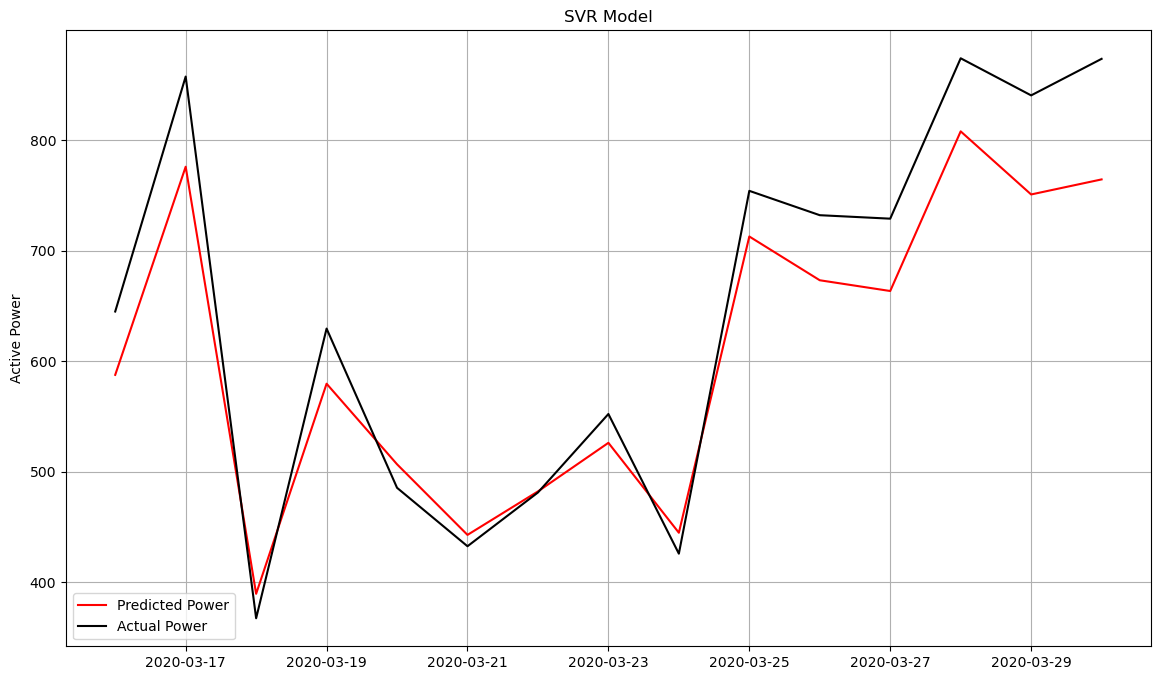

In [28]:
### Plotting SVR Predictions
plt.figure(figsize=(14, 8))
plt.plot(df_svr['PredictedPower'], color='red', label='Predicted Power')
plt.plot(df_svr['ActualPower'], color='black', label='Actual Power')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.title("SVR Model")
plt.show()


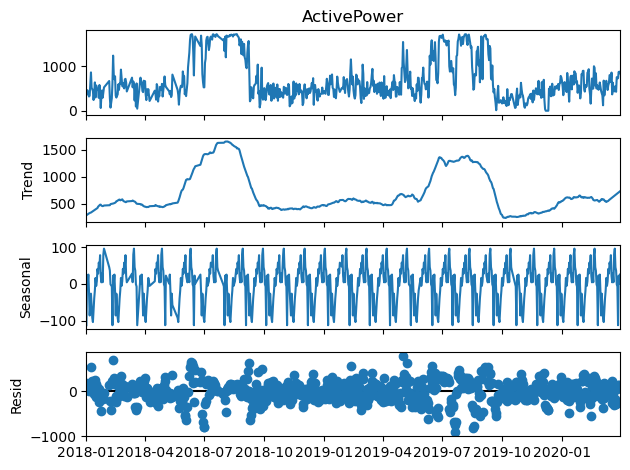

<Figure size 1400x800 with 0 Axes>

In [29]:
## SARIMAX
### Seasonal Nature of Data
result = seasonal_decompose(df_daily['ActivePower'].dropna(), period=31, model='additive', extrapolate_trend=True)
result.plot()
plt.figure(figsize=(14, 8))
plt.show()


In [30]:
## SARIMAX (with WindSpeed as exogenous variable)

### Splitting Data into Train and Test Sets
train_end = 733
train_y = df_daily['ActivePower'][:train_end]
test_y  = df_daily['ActivePower'][train_end:]
train_X = df_daily[['WindSpeed']][:train_end]
test_X  = df_daily[['WindSpeed']][train_end:]

### Auto ARIMA with exogenous regressor
sarimax_auto = pm.auto_arima(
    train_y, exogenous=train_X,
    seasonal=True, m=7,            # weekly seasonality
    stepwise=True, suppress_warnings=True, error_action="ignore",
    max_p=7, max_q=7, max_P=3, max_Q=3, d=None, D=None,
    random_state=20, n_fits=50
)
print(sarimax_auto.summary())

# Extract best parameters
p,d,q = sarimax_auto.order
P,D,Q,m = sarimax_auto.seasonal_order

### Timing + memory
tracemalloc.start()
sarimax_time_start = time.time()

sarimax_model = SARIMAX(train_y, exog=train_X, order=(p,d,q), seasonal_order=(P,D,Q,m))
sarimax_fit = sarimax_model.fit(disp=0)

sarimax_time_end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

sarimax_train_time = sarimax_time_end - sarimax_time_start
sarimax_memory_usage = peak / (1024 ** 2)


/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shrutisivakumar/miniconda3/envs/timeseries311

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  733
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -4966.003
Date:                Sun, 30 Nov 2025   AIC                           9942.005
Time:                        11:27:26   BIC                           9964.991
Sample:                             0   HQIC                          9950.872
                                - 733                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      7.8415      4.707      1.666      0.096      -1.385      17.068
ar.L1          1.4992      0.063     23.694      0.000       1.375       1.623
ar.L2         -0.5107      0.059     -8.624      0.0

/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
### Forecast with exogenous vars
sarimax_forecast = sarimax_fit.get_forecast(steps=len(test_y), exog=test_X)
sarimax_predictions = sarimax_forecast.predicted_mean
sarimax_predictions.index = test_y.index


/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/shrutisivakumar/miniconda3/envs/timeseries311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
### Evaluate SARIMAX
df_sarimax = pd.DataFrame({'ActualPower': test_y,
                          'PredictedPower': sarimax_predictions}, index=test_y.index)

sarimax_r2 = r2_score(df_sarimax['ActualPower'], df_sarimax['PredictedPower'])
sarimax_mae = mean_absolute_error(df_sarimax['ActualPower'], df_sarimax['PredictedPower'])
sarimax_mse = mean_squared_error(df_sarimax['ActualPower'], df_sarimax['PredictedPower'])
sarimax_rmse = math.sqrt(sarimax_mse)   # manual RMSE (avoid squared=False)
sarimax_mape = mean_absolute_percentage_error(df_sarimax['ActualPower'], df_sarimax['PredictedPower'])

print('SARIMAX Model Evaluation (with WindSpeed):')
print(f'R-squared: {sarimax_r2:.3f}')
print(f'MAE: {sarimax_mae:.2f}')
print(f'RMSE: {sarimax_rmse:.2f}')
print(f'MAPE: {sarimax_mape:.3f}')


SARIMAX Model Evaluation (with WindSpeed):
R-squared: 0.882
MAE: 51.06
RMSE: 59.17
MAPE: 0.077


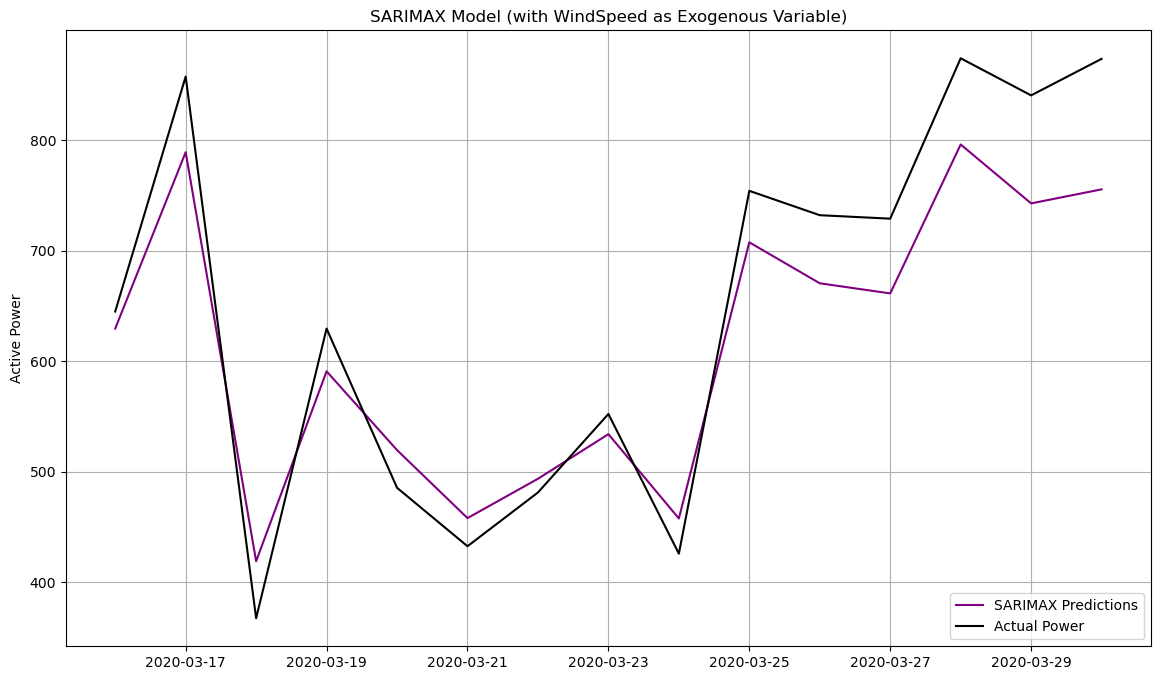

In [33]:

### Plot SARIMAX Predictions
plt.figure(figsize=(14, 8))
plt.plot(df_sarimax.index, df_sarimax['PredictedPower'], color='purple', label='SARIMAX Predictions')
plt.plot(df_sarimax.index, df_sarimax['ActualPower'], color='black', label='Actual Power')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.title("SARIMAX Model (with WindSpeed as Exogenous Variable)")
plt.show()

In [34]:
## XGB Regressor
### Splitting Data into Train and Test Sets
X_train_xgb, X_test_xgb = df_daily[['WindSpeed']][:733], df_daily[['WindSpeed']][733:748]
y_train_xgb, y_test_xgb = df_daily['ActivePower'][0:733],  df_daily['ActivePower'][733:748]

### Building and Training XGB Regressor Model
xgb_model = xgb.XGBRegressor(n_estimators=1000)

tracemalloc.start()
xgb_time_start = time.time()

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_test_xgb, y_test_xgb)],
    verbose=True
)

xgb_time_end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

xgb_train_time = xgb_time_end - xgb_time_start
xgb_memory_usage = peak / (1024 ** 2)


[0]	validation_0-rmse:323.93186	validation_1-rmse:133.80920
[1]	validation_0-rmse:231.38316	validation_1-rmse:101.34645
[2]	validation_0-rmse:166.91014	validation_1-rmse:80.83143
[3]	validation_0-rmse:122.64008	validation_1-rmse:68.44540
[4]	validation_0-rmse:92.71935	validation_1-rmse:62.66074
[5]	validation_0-rmse:73.23687	validation_1-rmse:59.87115
[6]	validation_0-rmse:61.02849	validation_1-rmse:57.79675
[7]	validation_0-rmse:53.71548	validation_1-rmse:56.97227
[8]	validation_0-rmse:49.43749	validation_1-rmse:57.48244
[1]	validation_0-rmse:231.38316	validation_1-rmse:101.34645
[2]	validation_0-rmse:166.91014	validation_1-rmse:80.83143
[3]	validation_0-rmse:122.64008	validation_1-rmse:68.44540
[4]	validation_0-rmse:92.71935	validation_1-rmse:62.66074
[5]	validation_0-rmse:73.23687	validation_1-rmse:59.87115
[6]	validation_0-rmse:61.02849	validation_1-rmse:57.79675
[7]	validation_0-rmse:53.71548	validation_1-rmse:56.97227
[8]	validation_0-rmse:49.43749	validation_1-rmse:57.48244
[9]	

In [35]:

### Making Predictions with XGB Regressor Model
xgb_predictions = xgb_model.predict(X_test_xgb)


In [36]:
### Evaluating XGB Regressor Model
df_xgb = pd.DataFrame({'ActualPower': y_test_xgb, 'PredictedPower': xgb_predictions}, index=y_test_xgb.index)
xgb_r2 = r2_score(df_xgb['ActualPower'], df_xgb['PredictedPower'])
xgb_mae = mean_absolute_error(df_xgb['ActualPower'], df_xgb['PredictedPower'])
xgb_mse = mean_squared_error(df_xgb['ActualPower'], df_xgb['PredictedPower'])
xgb_rmse = math.sqrt(xgb_mse)
xgb_mape = mean_absolute_percentage_error(df_xgb['ActualPower'], df_xgb['PredictedPower'])
print('XGBoost Model Evaluation:')
print(f'R-squared: {xgb_r2:.3f}')
print(f'MAE: {xgb_mae:.2f}')
print(f'RMSE: {xgb_rmse:.2f}')
print(f'MAPE: {xgb_mape:.3f}')



XGBoost Model Evaluation:
R-squared: 0.847
MAE: 53.32
RMSE: 67.49
MAPE: 0.078


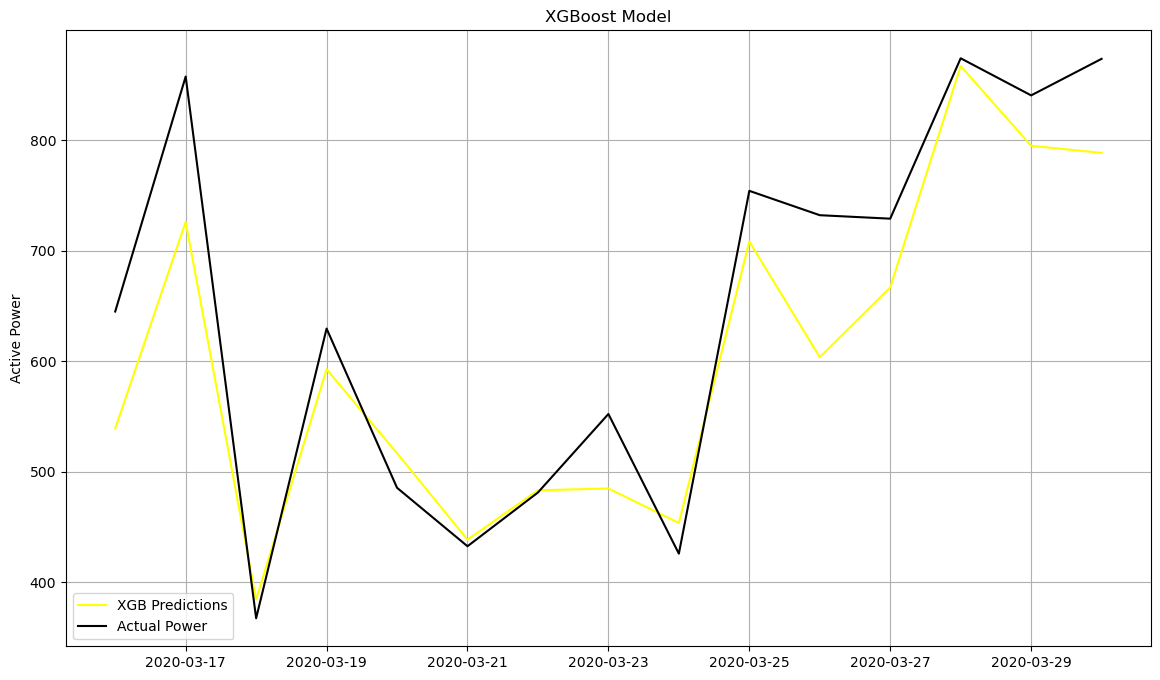

In [37]:

### Plotting XGBoost Predictions
plt.figure(figsize=(14, 8))
plt.plot(df_xgb.index, df_xgb['PredictedPower'], color='yellow', label='XGB Predictions')
plt.plot(df_xgb.index, df_xgb['ActualPower'], color='black', label='Actual Power')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.title("XGBoost Model")
plt.show()


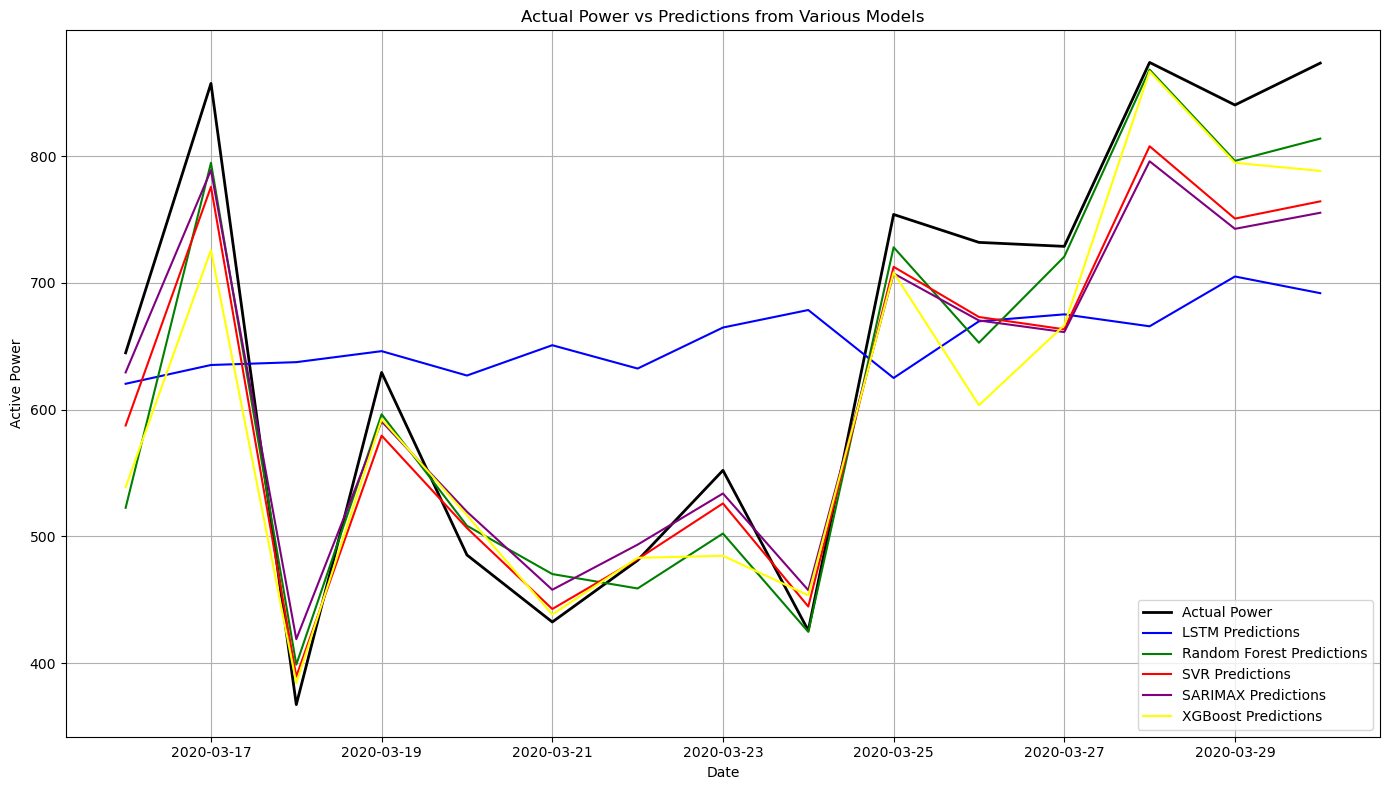

In [38]:
## Comparison
### Combine Predictions from All Models
df_combined = pd.DataFrame({
    'ActualPower': y_test_rf.values.flatten(),
    'LSTM_Predictions': df_lstm['PredictedPower'].values,
    'RF_Predictions': df_rf['PredictedPower'].values,
    'SVR_Predictions': df_svr['PredictedPower'].values,
    'SARIMAX_Predictions': df_sarimax['PredictedPower'].values,
    'XGBoost_Predictions': df_xgb['PredictedPower'].values
}, index=y_test_rf.index)

### Plotting All Predictions Together
plt.figure(figsize=(14, 8))
plt.plot(df_combined.index, df_combined['ActualPower'], color='black', linewidth=2, label='Actual Power')
plt.plot(df_combined.index, df_combined['LSTM_Predictions'], color='blue', label='LSTM Predictions')
plt.plot(df_combined.index, df_combined['RF_Predictions'], color='green', label='Random Forest Predictions')
plt.plot(df_combined.index, df_combined['SVR_Predictions'], color='red', label='SVR Predictions')
plt.plot(df_combined.index, df_combined['SARIMAX_Predictions'], color='purple', label='SARIMAX Predictions')
plt.plot(df_combined.index, df_combined['XGBoost_Predictions'], color='yellow', label='XGBoost Predictions')
plt.title('Actual Power vs Predictions from Various Models')
plt.xlabel('Date')
plt.ylabel('Active Power')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [39]:
### Prepare Evaluation Metrics for Plotting
metrics = ['R-squared', 'MAE', 'RMSE', 'MAPE']
lstm_metrics = [r2_lstm, mae_lstm, rmse_lstm, mape_lstm]
rf_metrics = [r2_rf, mae_rf, rmse_rf, mape_rf]
svr_metrics = [r2_svr, mae_svr, rmse_svr, mape_svr]
sarimax_metrics = [sarimax_r2, sarimax_mae, sarimax_rmse, sarimax_mape]
xgb_metrics = [xgb_r2, xgb_mae, xgb_rmse, xgb_mape]
metrics_df = pd.DataFrame({
    'Metric': metrics,
    'LSTM': lstm_metrics,
    'Random Forest': rf_metrics,
    'SVR': svr_metrics,
    'SARIMAX': sarimax_metrics,
    'XGBoost': xgb_metrics
})

print(metrics_df)
metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Value')


      Metric        LSTM  Random Forest        SVR    SARIMAX    XGBoost
0  R-squared    0.083955       0.913839   0.891739   0.882253   0.846792
1        MAE  145.353152      40.395318  47.928039  51.055414  53.317896
2       RMSE  165.027153      50.611756  56.732650  59.165880  67.489776
3       MAPE    0.260318       0.063702   0.067799   0.076520   0.078204



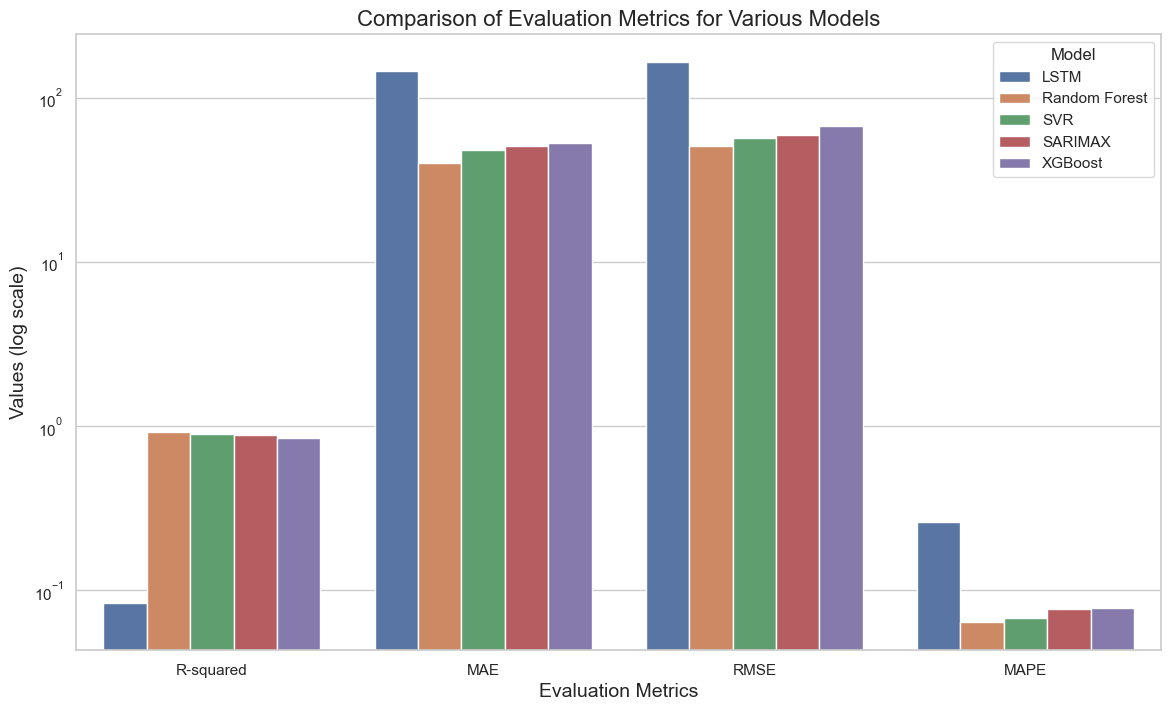

In [40]:
### Plot Evaluation Metrics
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df_melted)
plt.title('Comparison of Evaluation Metrics for Various Models', fontsize=16)
plt.xlabel('Evaluation Metrics', fontsize=14)
plt.ylabel('Values (log scale)', fontsize=14)
plt.yscale('log')
plt.legend(title='Model')
plt.show()


In [41]:

# >>> CHANGED: Add a compact time & memory comparison table
time_mem_df = pd.DataFrame({
    'Model': ['LSTM', 'Random Forest', 'SVR', 'SARIMAX', 'XGBoost'],
    'Training Time (s)': [lstm_time, rf_time, svr_train_time, sarimax_train_time, xgb_train_time],
    'Memory Usage (MB)': [lstm_mem, rf_mem, svr_memory_usage, sarimax_memory_usage, xgb_memory_usage]
})
print("=== Model Time and Memory Usage Comparison Table ===")
print(time_mem_df.to_string(index=False))

=== Model Time and Memory Usage Comparison Table ===
        Model  Training Time (s)  Memory Usage (MB)
         LSTM          57.949723           9.490744
Random Forest           4.533452           1.089214
          SVR           0.003392           0.014835
      SARIMAX           0.318852           1.422847
      XGBoost           1.245633           0.420141


In [42]:
# Fix the index by resetting it into a column named 'Date'

# 1. LSTM
df_lstm_reset = df_lstm.reset_index()
df_lstm_reset.to_csv('LSTM.csv', index=False)

# 2. Random Forest
df_rf_reset = df_rf.reset_index()
df_rf_reset.to_csv('RF.csv', index=False)

# 3. SVR
df_svr_reset = df_svr.reset_index()
df_svr_reset.to_csv('SVR.csv', index=False)

# 4. SARIMA
df_sarima_reset = df_sarimax.reset_index()
df_sarima_reset.to_csv('SARIMAX.csv', index=False)

# 5. XGBoost
df_xgb_reset = df_xgb.reset_index()
df_xgb_reset.to_csv('XGB.csv', index=False)
